courbe taux chomage moyen en france

In [1]:
import pandas as pd
import plotly.express as px

# Recharger le DataFrame si besoin
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';', encoding='utf-8')

# Liste des colonnes de trimestres
trimestres = [col for col in df.columns if "20" in col and "-T" in col]

# Moyenne nationale à chaque trimestre
moyennes = df[trimestres].mean()

# Créer un DataFrame pour la courbe
courbe_df = pd.DataFrame({
    "Trimestre": moyennes.index,
    "Taux de chômage moyen (%)": moyennes.values
})

# Tracer la courbe
fig = px.line(
    courbe_df,
    x="Trimestre",
    y="Taux de chômage moyen (%)",
    title="Évolution du taux de chômage moyen en France",
    markers=True
)

fig.update_layout(
    xaxis_title="Trimestre",
    yaxis_title="Taux de chômage (%)",
    yaxis=dict(tickformat=".1f"),
    template="plotly_white"
)
fig.write_image("courbe_moyenne_chomage.png")
fig.show()

histogramme taux moyen chomage par trimestre

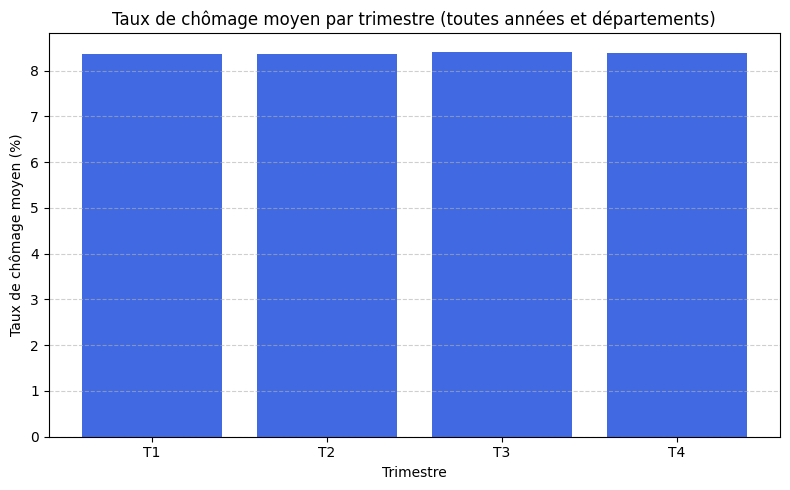

{'T1': np.float64(8.356557765151512), 'T2': np.float64(8.372868217054263), 'T3': np.float64(8.408212209302325), 'T4': np.float64(8.382218992248063)}


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire le CSV avec le bon séparateur
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';')


# Sélectionner les colonnes par trimestre
colonnes_T1 = [col for col in df.columns if "-T1" in col]
colonnes_T2 = [col for col in df.columns if "-T2" in col]
colonnes_T3 = [col for col in df.columns if "-T3" in col]
colonnes_T4 = [col for col in df.columns if "-T4" in col]

# Aplatir toutes les valeurs de toutes les colonnes par trimestre et convertir en numérique
T1_vals = pd.to_numeric(df[colonnes_T1].values.flatten(), errors='coerce')
T2_vals = pd.to_numeric(df[colonnes_T2].values.flatten(), errors='coerce')
T3_vals = pd.to_numeric(df[colonnes_T3].values.flatten(), errors='coerce')
T4_vals = pd.to_numeric(df[colonnes_T4].values.flatten(), errors='coerce')

# Moyenne en ignorant les NaN
moyennes = {
    'T1': pd.Series(T1_vals).mean(),
    'T2': pd.Series(T2_vals).mean(),
    'T3': pd.Series(T3_vals).mean(),
    'T4': pd.Series(T4_vals).mean(),
}

# Tracé de l'histogramme
plt.figure(figsize=(8, 5))
plt.bar(moyennes.keys(), moyennes.values(), color='royalblue')

plt.title("Taux de chômage moyen par trimestre (toutes années et départements)")
plt.xlabel("Trimestre")
plt.ylabel("Taux de chômage moyen (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print(moyennes)

histogramme taux de chomage moyen par trimestre pour les départements touchés par le travail saisonnier estival

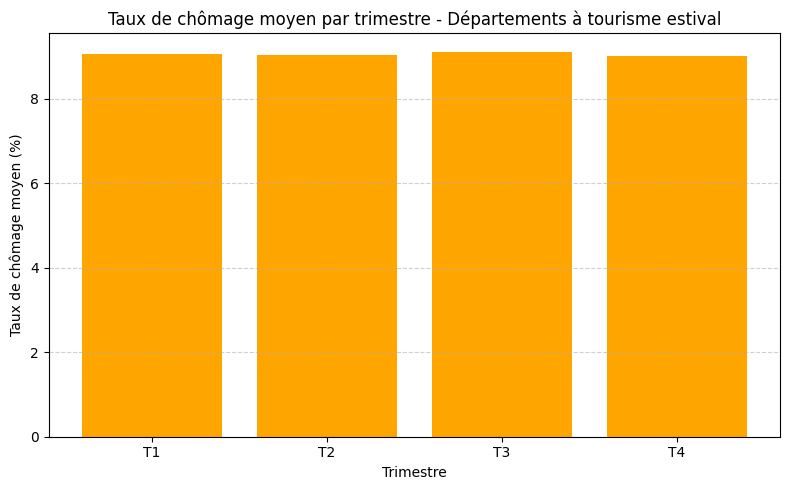

Moyennes trimestrielles pour les départements à tourisme estival :
{'T1': np.float64(9.069806094182825), 'T2': np.float64(9.03573407202216), 'T3': np.float64(9.111357340720222), 'T4': np.float64(9.011634349030471)}


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Liste des départements à tourisme estival
departements_tourisme_estival = [
"Hérault", "Var", "Charente-Maritime", "Vendée", "Pyrénées-Orientales",
"Alpes-Maritimes", "Corse-du-Sud", "Haute-Corse", "Gironde", "Finistère",
"Landes", "Morbihan", "Gard", "Aude", "Bouches-du-Rhône", "Savoie", "Haute-Savoie", "Dordogne", "Loire-Atlantique"
]

# Lecture du CSV
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';')

# Nettoyer les noms de départements dans la première colonne
col_nom_departement = df.columns[0]
df[col_nom_departement] = df[col_nom_departement].str.extract(r'-\s*(.*)')  # Extrait juste le nom après le tiret

# Filtrer uniquement les lignes correspondant aux départements ciblés
df_filtre = df[df[col_nom_departement].isin(departements_tourisme_estival)]

# Filtrage des colonnes récentes uniquement (à partir de 2005 par ex)
colonnes_recentes = [col for col in df_filtre.columns if any(str(annee) in col for annee in range(2005, 2024))]

# Ensuite, filtrer les colonnes T1-T4 parmi celles-ci
colonnes_T1 = [col for col in colonnes_recentes if "-T1" in col]
colonnes_T2 = [col for col in colonnes_recentes if "-T2" in col]
colonnes_T3 = [col for col in colonnes_recentes if "-T3" in col]
colonnes_T4 = [col for col in colonnes_recentes if "-T4" in col]

# Aplatir les valeurs et convertir en numérique
T1_vals = pd.to_numeric(df_filtre[colonnes_T1].values.flatten(), errors='coerce')
T2_vals = pd.to_numeric(df_filtre[colonnes_T2].values.flatten(), errors='coerce')
T3_vals = pd.to_numeric(df_filtre[colonnes_T3].values.flatten(), errors='coerce')
T4_vals = pd.to_numeric(df_filtre[colonnes_T4].values.flatten(), errors='coerce')

# Moyennes par trimestre
moyennes = {
    'T1': pd.Series(T1_vals).mean(),
    'T2': pd.Series(T2_vals).mean(),
    'T3': pd.Series(T3_vals).mean(),
    'T4': pd.Series(T4_vals).mean(),
}

# Tracé de l'histogramme
plt.figure(figsize=(8, 5))
plt.bar(moyennes.keys(), moyennes.values(), color='orange')

plt.title("Taux de chômage moyen par trimestre - Départements à tourisme estival")
plt.xlabel("Trimestre")
plt.ylabel("Taux de chômage moyen (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Moyennes trimestrielles pour les départements à tourisme estival :")
print(moyennes)


Top 10 des départements avec la plus forte variation saisonnière du taux de chômage 

In [4]:
import pandas as pd
import numpy as np

# Charger le fichier CSV
df = pd.read_csv("valeurs_trimestrielles_sans_codes.csv", sep=';')

# Extraire le nom du département propre
col_nom_dep = df.columns[0]
df[col_nom_dep] = df[col_nom_dep].str.extract(r'-\s*(.*)')

# Filtrage des colonnes récentes uniquement (à partir de 2005 par ex)
colonnes_recentes = [col for col in df.columns if any(str(annee) in col for annee in range(2005, 2024))]

# Ensuite, filtrer les colonnes T1-T4 parmi celles-ci
colonnes_T1 = [col for col in colonnes_recentes if "-T1" in col]
colonnes_T2 = [col for col in colonnes_recentes if "-T2" in col]
colonnes_T3 = [col for col in colonnes_recentes if "-T3" in col]
colonnes_T4 = [col for col in colonnes_recentes if "-T4" in col]

# Initialiser une liste de résultats
resultats = []

# Boucle sur chaque département
for _, ligne in df.iterrows():
    nom_dep = ligne[col_nom_dep]

    # Extraire les valeurs pour chaque trimestre
    T1 = pd.to_numeric(ligne[colonnes_T1], errors='coerce')
    T2 = pd.to_numeric(ligne[colonnes_T2], errors='coerce')
    T3 = pd.to_numeric(ligne[colonnes_T3], errors='coerce')
    T4 = pd.to_numeric(ligne[colonnes_T4], errors='coerce')

    # Moyenne par trimestre
    moy_T1 = T1.mean()
    moy_T2 = T2.mean()
    moy_T3 = T3.mean()
    moy_T4 = T4.mean()

    # Écart-type de ces moyennes = indicateur de variation saisonnière
    ecart_type = np.std([moy_T1, moy_T2, moy_T3, moy_T4])

    resultats.append({
        'Département': nom_dep,
        'Écart-type saisonnier': ecart_type,
        'Moyennes T1-T4': [moy_T1, moy_T2, moy_T3, moy_T4]
    })

# Convertir en DataFrame et trier
df_resultats = pd.DataFrame(resultats)
df_resultats_sorted = df_resultats.sort_values(by='Écart-type saisonnier', ascending=False)

# Afficher les 10 départements avec la plus forte variation saisonnière
print("Top 10 des départements avec la plus forte variation saisonnière du taux de chômage :")
print(df_resultats_sorted.head(10).to_string(index=False))


Top 10 des départements avec la plus forte variation saisonnière du taux de chômage :
        Département  Écart-type saisonnier                                                                   Moyennes T1-T4
Pyrénées-Orientales               0.070121 [12.789473684210526, 12.715789473684211, 12.910526315789474, 12.826315789473686]
        Haute-Corse               0.059894                                 [8.910526315789474, 8.9, 9.0, 8.831578947368422]
    Tarn-et-Garonne               0.056364                   [9.7, 9.605263157894736, 9.757894736842108, 9.721052631578948]
  Charente-Maritime               0.056318        [9.04736842105263, 9.021052631578948, 9.08421052631579, 8.93157894736842]
              Paris               0.054490    [7.510526315789474, 7.4421052631578934, 7.531578947368421, 7.394736842105263]
             Ariège               0.053674  [10.431578947368422, 10.389473684210527, 10.536842105263158, 10.45263157894737]
               Nord               0.052681 [11